In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('email_data.csv')

In [7]:
df.head

<bound method NDFrame.head of      Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [8]:
df.rename(columns={
    "Category": "target",
    "Message": "text"
}, inplace=True)

In [9]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.info

<bound method DataFrame.info of      target                                               text
0       ham  Go until jurong point, crazy.. Available only ...
1       ham                      Ok lar... Joking wif u oni...
2      spam  Free entry in 2 a wkly comp to win FA Cup fina...
3       ham  U dun say so early hor... U c already then say...
4       ham  Nah I don't think he goes to usf, he lives aro...
...     ...                                                ...
5567   spam  This is the 2nd time we have tried 2 contact u...
5568    ham               Will ü b going to esplanade fr home?
5569    ham  Pity, * was in mood for that. So...any other s...
5570    ham  The guy did some bitching but I acted like i'd...
5571    ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>

In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (5572, 2)

Columns:
Index(['target', 'text'], dtype='str')


In [12]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
target    0
text      0
dtype: int64


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 415


In [14]:
print("Duplicates after removal:", df.duplicated().sum())
print("Shape:", df.shape)

Duplicates after removal: 415
Shape: (5572, 2)


In [15]:
df_model = df.copy()

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["target"] = encoder.fit_transform(df["target"])

In [17]:
df[["target", "text"]].head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
print(encoder.classes_)

['ham' 'spam']


In [19]:
df["target"].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

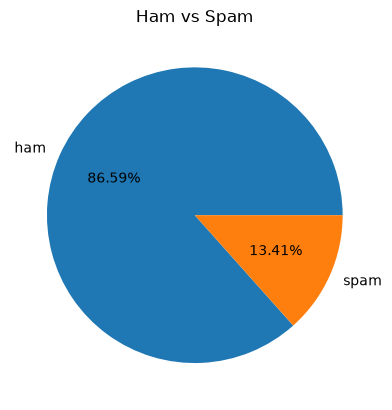

In [20]:
plt.pie(
    df["target"].value_counts(),
    labels=["ham", "spam"],
    autopct="%0.2f%%"
)

plt.title("Ham vs Spam")
plt.show()

In [21]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df["num_characters"] = df["text"].apply(len)

In [23]:
df["num_words"] = df["text"].apply(
    lambda x: len(nltk.word_tokenize(x))
)

In [24]:
df["num_sentences"] = df["text"].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [25]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


Text preprocessing

In [26]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download("stopwords")

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def transform_text(text):
    text = text.lower()
    
    tokens = nltk.word_tokenize(text)
    
    tokens = [
        word for word in tokens
        if word.isalnum()
    ]
    
    tokens = [
        word for word in tokens
        if word not in stopwords.words("english")
        and word not in string.punctuation
    ]
    
    tokens = [
        ps.stem(word)
        for word in tokens
    ]
    
    return " ".join(tokens)

In [28]:
transform_text(
    "Congrats! You have won a free prize!"
)

'congrat free prize'

Apply preprocessing

In [29]:
df["transformed_text"] = df["text"].apply(transform_text)

In [30]:
df[["text", "transformed_text"]].head()

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df["transformed_text"]).toarray()

In [32]:
X.shape

(5572, 3000)

In [33]:
y = df["target"].values

Train/test split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [37]:
from sklearn.svm import SVC

svc = SVC(kernel="linear")

svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [39]:
print("Naive Bayes")
print(classification_report(
    y_test,
    y_pred_mnb,
    target_names=["Ham", "Spam"]
))

Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [40]:
print("Logistic Regression")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Ham", "Spam"]
))

Logistic Regression
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       966
        Spam       1.00      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [41]:
print("SVM")
print(classification_report(
    y_test,
    y_pred_svc,
    target_names=["Ham", "Spam"]
))

SVM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



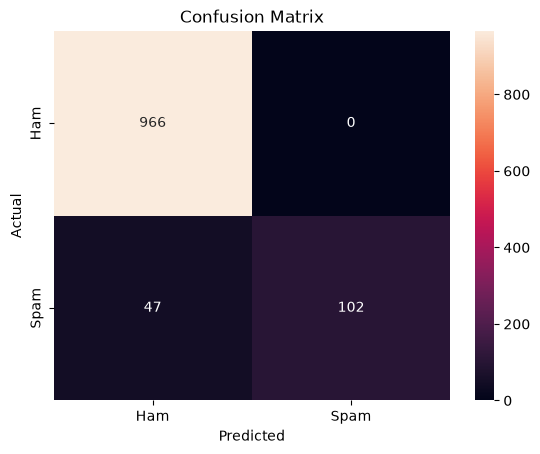

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Test your own message

In [43]:
message = [
    "hey durvesh here is your offer letter!"
]

In [44]:
message_tfidf = tfidf.transform(message)

In [45]:
prediction = lr.predict(message_tfidf)

In [46]:
if prediction[0] == 1:
    print("SPAM")
else:
    print("HAM")

HAM


In [54]:
y_pred = mnb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9766816143497757
Precision: 1.0
Recall   : 0.825503355704698
F1 Score : 0.9044117647058824

Confusion Matrix:
[[966   0]
 [ 26 123]]


In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.957847533632287
Precision: 1.0
Recall   : 0.6845637583892618
F1 Score : 0.8127490039840638

Confusion Matrix:
[[966   0]
 [ 47 102]]


In [56]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')

svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall   :", recall_score(y_test, y_pred_svc))
print("F1 Score :", f1_score(y_test, y_pred_svc))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

SVM
Accuracy : 0.9829596412556054
Precision: 0.9779411764705882
Recall   : 0.8926174496644296
F1 Score : 0.9333333333333333

Confusion Matrix:
[[963   3]
 [ 16 133]]


In [57]:
import pickle

# Save Multinomial Naive Bayes model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(mnb, f)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [58]:
import os

print("Model:", os.path.exists("spam_model.pkl"))
print("Vectorizer:", os.path.exists("tfidf_vectorizer.pkl"))

Model: True
Vectorizer: True


In [82]:
def predict_spam(message):
    # Apply the same preprocessing used during training
    transformed_message = transform_text(message)

    # Convert to TF-IDF
    message_vector = tfidf.transform([transformed_message])

    # Predict using Naive Bayes
    prediction = mnb.predict(message_vector)[0]

    if prediction == 1:
        return "SPAM 🚨"
    else:
        return "HAM ✅"

In [81]:
message = "Congratulations! You won 1 crore rupees. Click this link now!"

print("Prediction:", predict_spam(message))

Prediction: SPAM 🚨


In [79]:
import pickle

with open("spam_model.pkl", "wb") as f:
    pickle.dump(mnb, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Final Naive Bayes model saved successfully!")

Final Naive Bayes model saved successfully!


In [83]:
message = "congrats you win one core rs"

print("Prediction:", predict_spam(message))

Prediction: HAM ✅


In [86]:
test_messages = [
    "Congratulations! You won 1 crore rupees. Click this link now!",
    "Congratulations! You have won a cash prize. Call now to claim your reward!",
    "Free entry! You have been selected to win a prize. Click here now!",
    "Hey bro, are you coming to college tomorrow?",
    "Can you send me the notes from today's lecture?"
]

for msg in test_messages:
    print("Message:", msg)
    print("Prediction:", predict_spam(msg))
    print("-" * 60)

Message: Congratulations! You won 1 crore rupees. Click this link now!
Prediction: SPAM 🚨
------------------------------------------------------------
Message: Congratulations! You have won a cash prize. Call now to claim your reward!
Prediction: SPAM 🚨
------------------------------------------------------------
Message: Free entry! You have been selected to win a prize. Click here now!
Prediction: SPAM 🚨
------------------------------------------------------------
Message: Hey bro, are you coming to college tomorrow?
Prediction: HAM ✅
------------------------------------------------------------
Message: Can you send me the notes from today's lecture?
Prediction: HAM ✅
------------------------------------------------------------
